<center><h1>TP 4: Réseaux de Neurones Convolutifs- Optimsation et regularisation</h1></center>

## Avant de commencer le TP,
- vérifiez que vous êtes sur un environnement GPU et python 3 :
  
  Éxecution -> Modifier le type d'éxecution -> Type d'éxecution = python3, Accélerateur matériel = GPU

- Fichier -> Sauvegarder une copie dans mon drive

In [1]:
! wget https://raw.githubusercontent.com/deep-learning-polytech/deep-learning-polytech.github.io/master/code/TP5-6/utils.py

--2026-04-23 23:41:35--  https://raw.githubusercontent.com/deep-learning-polytech/deep-learning-polytech.github.io/master/code/TP5-6/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2627 (2.6K) [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]   2.57K  --.-KB/s    in 0s      

2026-04-23 23:41:35 (55.1 MB/s) - ‘utils.py’ saved [2627/2627]



In [2]:
import argparse
import os
import time

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim
import torch.utils.data
import torchvision.transforms as transforms
import torchvision.datasets as datasets

from utils import *

PRINT_INTERVAL = 200
PATH="datasets"

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvNet(nn.Module):
    """
    This class contains the neural network structure
    """
    def __init__(self):
        super(ConvNet, self).__init__()
        # First, we define the convolution and pooling layers
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, (5, 5), stride=1, padding=2),
            nn.Tanh(),
            nn.MaxPool2d((2, 2), stride=2, padding=0),
            nn.Conv2d(6, 16, (5, 5), stride=1, padding=0),
            nn.Tanh(),
            nn.MaxPool2d((2, 2), stride=2, padding=0),
        )
        # We define the fully connected layers
        self.classifier = nn.Sequential(
            nn.Linear(400, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10)
        )

    def forward(self, input):
        bsize = input.size(0) # batch size
        output = self.features(input) # compute the output of the conv layers
        output = output.view(bsize, -1) # flatten the 2D feature maps into 1D
        output = self.classifier(output) # compute the output of the fc layers
        return output

def get_dataset(batch_size, cuda=False):
    """
    Cette fonction charge le dataset et effectue des transformations sur chaqu
    image (listées dans `transform=...`).
    """
    train_dataset = datasets.MNIST(PATH, train=True, download=True,
        transform=transforms.Compose([
            transforms.ToTensor()
        ]))
    val_dataset = datasets.MNIST(PATH, train=False, download=True,
        transform=transforms.Compose([
            transforms.ToTensor()
        ]))

    train_loader = torch.utils.data.DataLoader(train_dataset,
                        batch_size=batch_size, shuffle=True, pin_memory=cuda, num_workers=2)
    val_loader = torch.utils.data.DataLoader(val_dataset,
                        batch_size=batch_size, shuffle=False, pin_memory=cuda, num_workers=2)

    return train_loader, val_loader



def epoch(data, model, criterion, optimizer=None, cuda=False):
    """
    Fait une passe (appelée epoch en anglais) sur les données `data` avec le
    modèle `model`. Evalue `criterion` comme loss.
    Si `optimizer` est fourni, effectue une epoch d'apprentissage en utilisant
    l'optimiseur donné, sinon, effectue une epoch d'évaluation (pas de backward)
    du modèle.
    """

    # indique si le modele est en mode eval ou train (certaines couches se
    # comportent différemment en train et en eval)
    model.eval() if optimizer is None else model.train()

    # objets pour stocker les moyennes des metriques
    avg_loss = AverageMeter()
    avg_top1_acc = AverageMeter()
    avg_top5_acc = AverageMeter()
    avg_batch_time = AverageMeter()
    global loss_plot

    # on itere sur les batchs du dataset
    tic = time.time()
    for i, (input, target) in enumerate(data):

        if cuda: # si on fait du GPU, passage en CUDA
            input = input.cuda()
            target = target.cuda()

        # forward
        output = model(input)
        loss = criterion(output, target)

        # backward si on est en "train"
        if optimizer:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # calcul des metriques
        prec1, prec5 = accuracy(output, target, topk=(1, 5))
        batch_time = time.time() - tic
        tic = time.time()

        # mise a jour des moyennes
        avg_loss.update(loss.item())
        avg_top1_acc.update(prec1.item())
        avg_top5_acc.update(prec5.item())
        avg_batch_time.update(batch_time)
        if optimizer:
            loss_plot.update(avg_loss.val)
        # affichage des infos
        if i % PRINT_INTERVAL == 0:
            print('[{0:s} Batch {1:03d}/{2:03d}]\t'
                  'Time {batch_time.val:.3f}s ({batch_time.avg:.3f}s)\t'
                  'Loss {loss.val:.4f} ({loss.avg:.4f})\t'
                  'Prec@1 {top1.val:5.1f} ({top1.avg:5.1f})\t'
                  'Prec@5 {top5.val:5.1f} ({top5.avg:5.1f})'.format(
                   "EVAL" if optimizer is None else "TRAIN", i, len(data), batch_time=avg_batch_time, loss=avg_loss,
                   top1=avg_top1_acc, top5=avg_top5_acc))
            if optimizer:
                loss_plot.plot()

    # Affichage des infos sur l'epoch
    print('\n===============> Total time {batch_time:d}s\t'
          'Avg loss {loss.avg:.4f}\t'
          'Avg Prec@1 {top1.avg:5.2f} %\t'
          'Avg Prec@5 {top5.avg:5.2f} %\n'.format(
           batch_time=int(avg_batch_time.sum), loss=avg_loss,
           top1=avg_top1_acc, top5=avg_top5_acc))

    return avg_top1_acc, avg_top5_acc, avg_loss


def main(batch_size=128, lr=0.1, epochs=5, cuda=False):

    # ex de params :
    #   {"batch_size": 128, "epochs": 5, "lr": 0.1}

    # define model, loss, optim
    model = ConvNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr)

    if cuda: # si on fait du GPU, passage en CUDA
        cudnn.benchmark = True
        model = model.cuda()
        criterion = criterion.cuda()

    # On récupère les données
    train, test = get_dataset(batch_size, cuda)

    # init plots
    plot = AccLossPlot()
    global loss_plot
    loss_plot = TrainLossPlot()

    # On itère sur les epochs
    for i in range(epochs):
        print("=================\n=== EPOCH "+str(i+1)+" =====\n=================\n")
        # Phase de train
        top1_acc, avg_top5_acc, loss = epoch(train, model, criterion, optimizer, cuda)
        # Phase d'evaluation
        top1_acc_test, top5_acc_test, loss_test = epoch(test, model, criterion, cuda=cuda)
        # plot
        plot.update(loss.avg, loss_test.avg, top1_acc.avg, top1_acc_test.avg)


In [4]:
class ConvNet_Optimized(nn.Module):
    def __init__(self):
        super(ConvNet_Optimized, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, (5, 5), stride=1, padding=2),
            nn.BatchNorm2d(6), # Batch Norm after the convolution
            nn.ReLU(),         # ReLU often performs better than Tanh
            nn.MaxPool2d((2, 2), stride=2, padding=0),

            nn.Conv2d(6, 16, (5, 5), stride=1, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d((2, 2), stride=2, padding=0),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(400, 120),
            nn.ReLU(),
            nn.Dropout(p=0.5), # Addition of Dropout (50%) to limit overfitting
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(84, 10)
        )

    def forward(self, input):
        output = self.features(input)
        output = self.classifier(output)
        return output

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.22MB/s]

=== EPOCH 1 =====



[TRAIN Batch 000/469]	Time 1.899s (1.899s)	Loss 2.3131 (2.3131)	Prec@1   7.0 (  7.0)	Prec@5  42.2 ( 42.2)


<Figure size 640x480 with 0 Axes>

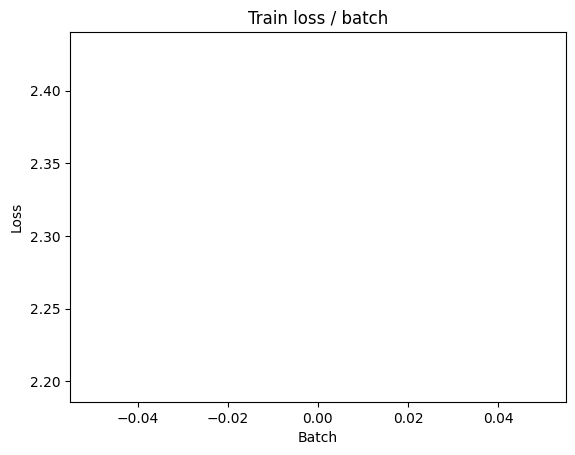

[TRAIN Batch 200/469]	Time 0.018s (0.025s)	Loss 0.4221 (1.1299)	Prec@1  91.4 ( 68.6)	Prec@5  98.4 ( 92.1)


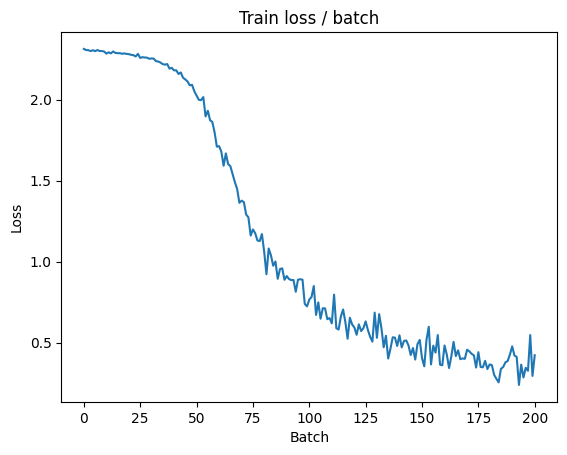

[TRAIN Batch 400/469]	Time 0.015s (0.020s)	Loss 0.2957 (0.6802)	Prec@1  92.2 ( 81.0)	Prec@5  99.2 ( 95.9)


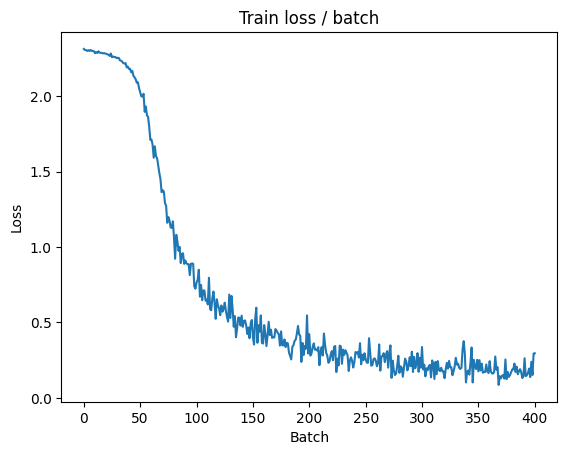


===============> Total time 9s	Avg loss 0.6046	Avg Prec@1 83.15 %	Avg Prec@5 96.46 %

[EVAL Batch 000/079]	Time 0.097s (0.097s)	Loss 0.0916 (0.0916)	Prec@1  97.7 ( 97.7)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.1330	Avg Prec@1 96.27 %	Avg Prec@5 99.91 %



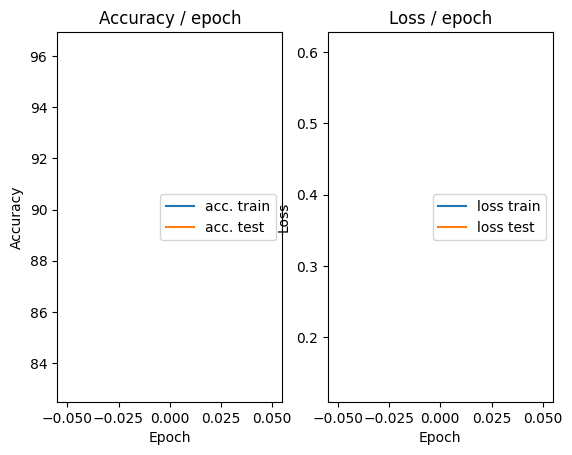

=== EPOCH 2 =====

[TRAIN Batch 000/469]	Time 0.106s (0.106s)	Loss 0.0990 (0.0990)	Prec@1  96.1 ( 96.1)	Prec@5 100.0 (100.0)


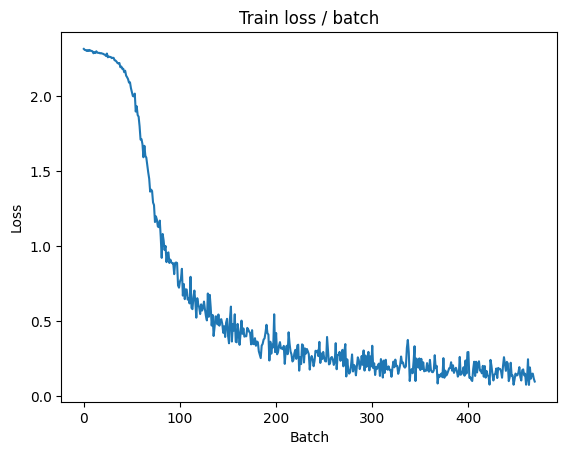

[TRAIN Batch 200/469]	Time 0.017s (0.023s)	Loss 0.0580 (0.1259)	Prec@1  96.9 ( 96.3)	Prec@5 100.0 ( 99.9)


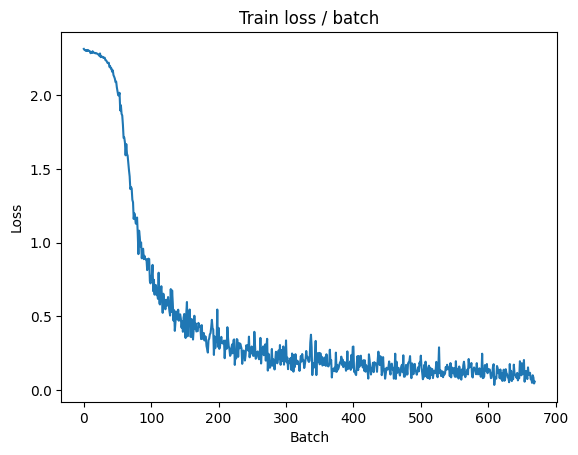

[TRAIN Batch 400/469]	Time 0.022s (0.019s)	Loss 0.0710 (0.1162)	Prec@1  96.9 ( 96.6)	Prec@5 100.0 ( 99.9)


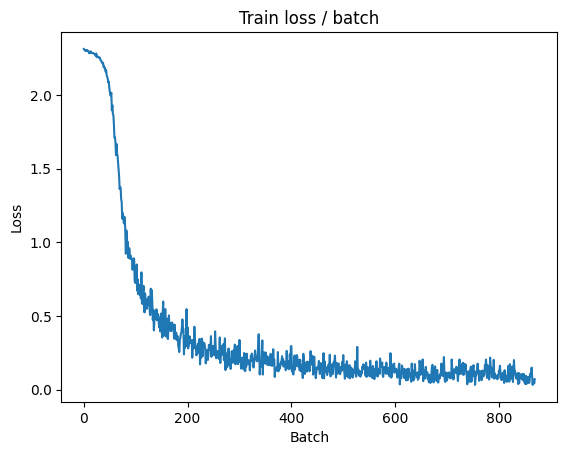


===============> Total time 8s	Avg loss 0.1119	Avg Prec@1 96.67 %	Avg Prec@5 99.91 %

[EVAL Batch 000/079]	Time 0.092s (0.092s)	Loss 0.0369 (0.0369)	Prec@1  99.2 ( 99.2)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0726	Avg Prec@1 97.77 %	Avg Prec@5 99.98 %



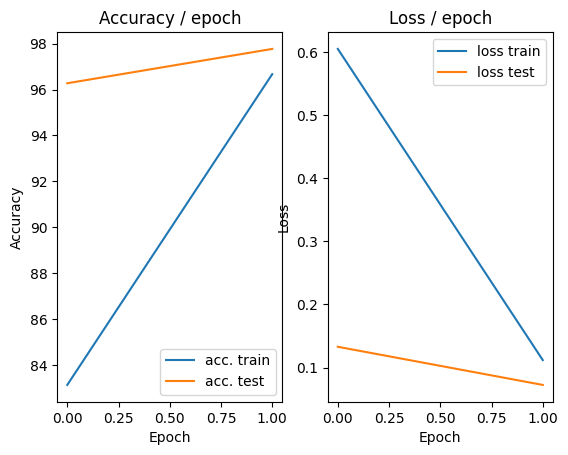

=== EPOCH 3 =====

[TRAIN Batch 000/469]	Time 0.109s (0.109s)	Loss 0.0642 (0.0642)	Prec@1  98.4 ( 98.4)	Prec@5 100.0 (100.0)


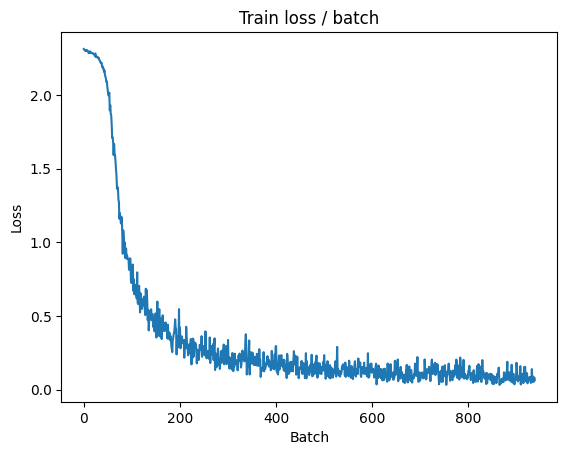

[TRAIN Batch 200/469]	Time 0.010s (0.016s)	Loss 0.0598 (0.0824)	Prec@1  98.4 ( 97.6)	Prec@5 100.0 (100.0)


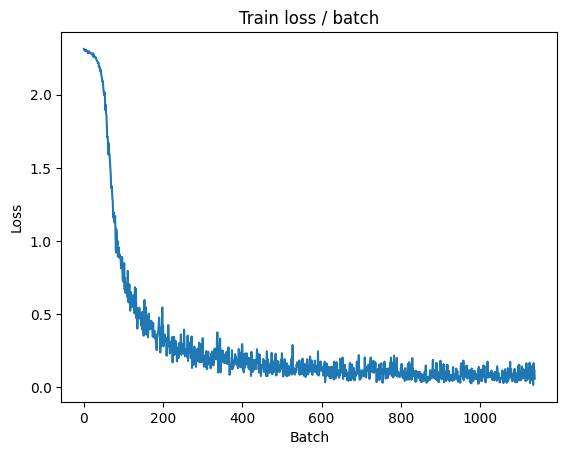

[TRAIN Batch 400/469]	Time 0.015s (0.018s)	Loss 0.1416 (0.0771)	Prec@1  94.5 ( 97.7)	Prec@5 100.0 (100.0)


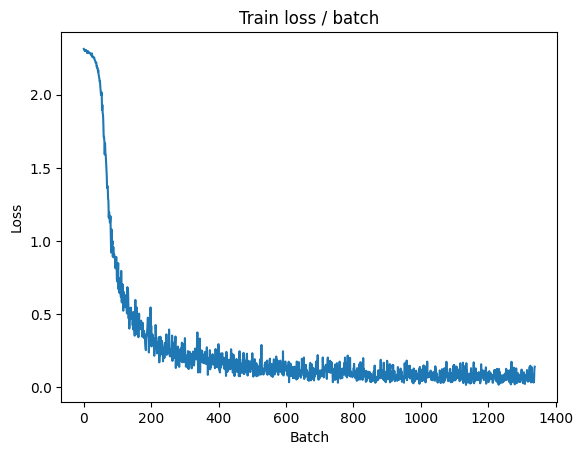


===============> Total time 8s	Avg loss 0.0766	Avg Prec@1 97.73 %	Avg Prec@5 99.95 %

[EVAL Batch 000/079]	Time 0.090s (0.090s)	Loss 0.0418 (0.0418)	Prec@1  98.4 ( 98.4)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0668	Avg Prec@1 97.87 %	Avg Prec@5 99.98 %



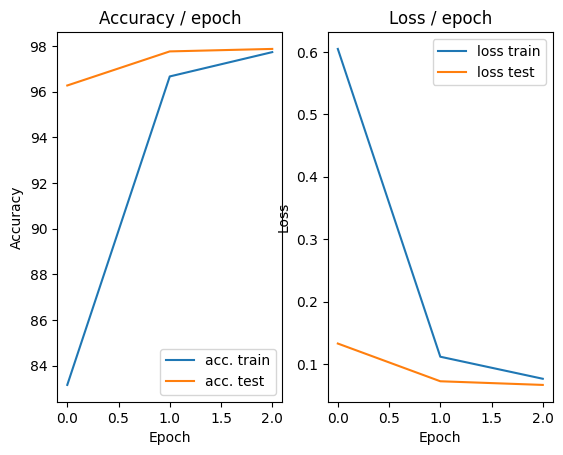

=== EPOCH 4 =====

[TRAIN Batch 000/469]	Time 0.100s (0.100s)	Loss 0.1018 (0.1018)	Prec@1  95.3 ( 95.3)	Prec@5 100.0 (100.0)


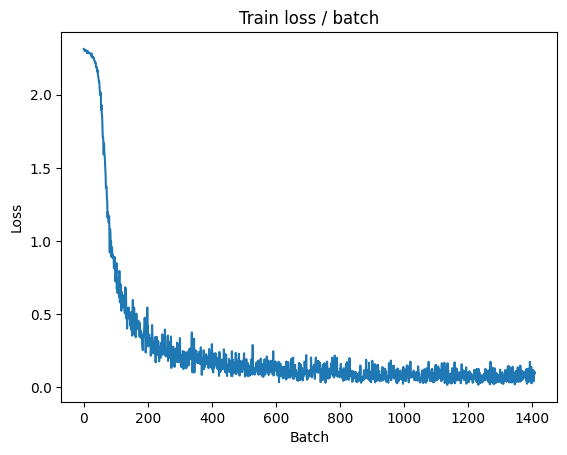

[TRAIN Batch 200/469]	Time 0.006s (0.016s)	Loss 0.0298 (0.0631)	Prec@1  99.2 ( 98.2)	Prec@5 100.0 ( 99.9)


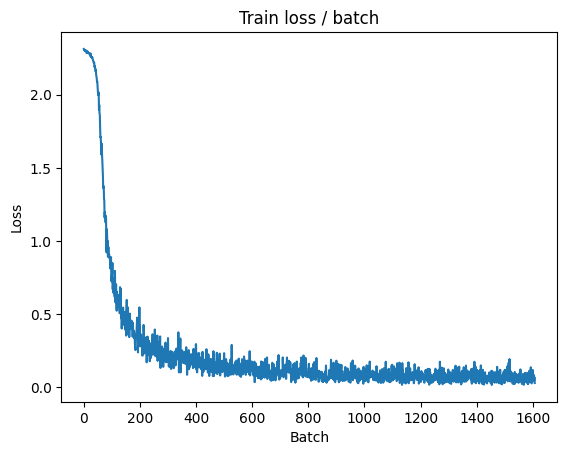

[TRAIN Batch 400/469]	Time 0.011s (0.016s)	Loss 0.0532 (0.0622)	Prec@1  99.2 ( 98.1)	Prec@5 100.0 (100.0)


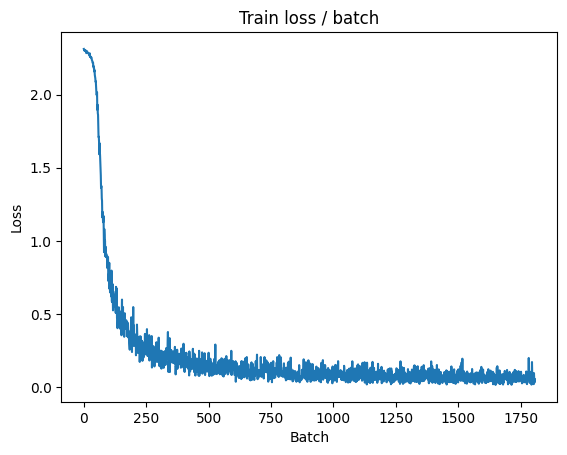


===============> Total time 8s	Avg loss 0.0614	Avg Prec@1 98.17 %	Avg Prec@5 99.96 %

[EVAL Batch 000/079]	Time 0.125s (0.125s)	Loss 0.0218 (0.0218)	Prec@1 100.0 (100.0)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0513	Avg Prec@1 98.43 %	Avg Prec@5 99.99 %



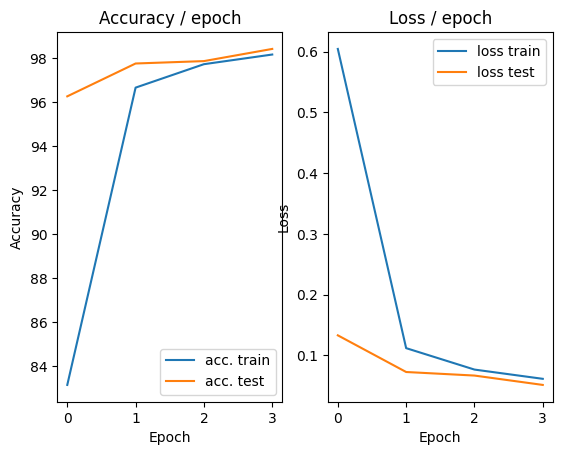

=== EPOCH 5 =====

[TRAIN Batch 000/469]	Time 0.111s (0.111s)	Loss 0.0254 (0.0254)	Prec@1 100.0 (100.0)	Prec@5 100.0 (100.0)


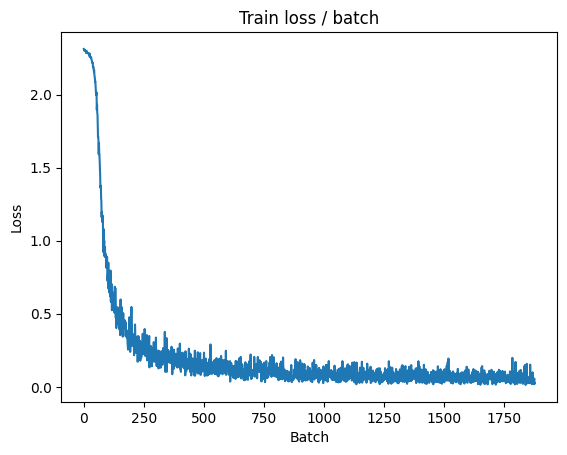

[TRAIN Batch 200/469]	Time 0.016s (0.016s)	Loss 0.0275 (0.0532)	Prec@1 100.0 ( 98.5)	Prec@5 100.0 (100.0)


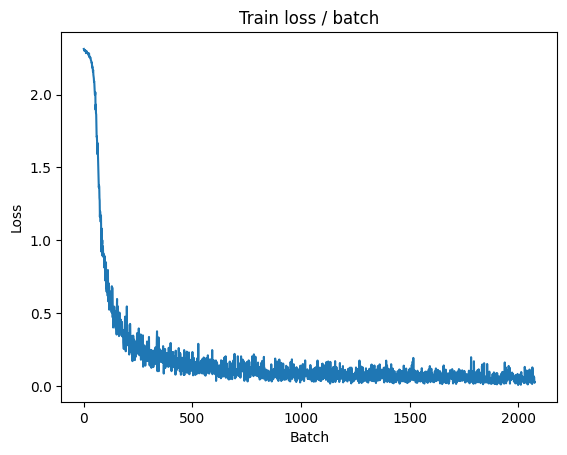

[TRAIN Batch 400/469]	Time 0.007s (0.017s)	Loss 0.0306 (0.0527)	Prec@1  99.2 ( 98.5)	Prec@5 100.0 (100.0)


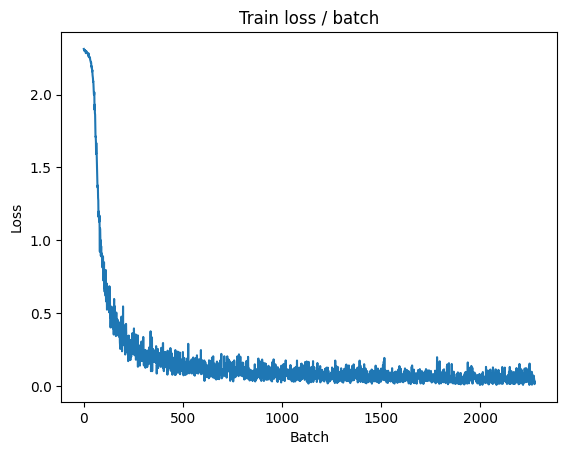


===============> Total time 8s	Avg loss 0.0518	Avg Prec@1 98.50 %	Avg Prec@5 99.98 %

[EVAL Batch 000/079]	Time 0.087s (0.087s)	Loss 0.0189 (0.0189)	Prec@1 100.0 (100.0)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0536	Avg Prec@1 98.32 %	Avg Prec@5 99.98 %



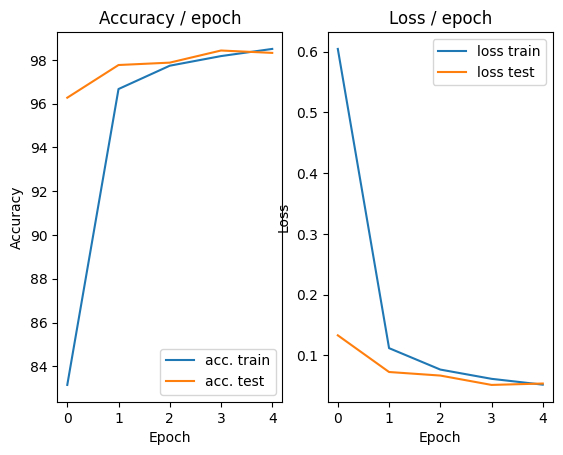

In [5]:
main(128, 0.1, cuda=True)